In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
df = load_diabetes(as_frame=True).frame

In [3]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
X = df.drop("target", axis=1)
y = df["target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=7, min_samples_split=20, min_samples_leaf=25)
model.fit(X_train, y_train)

# Without Pre-pruning or post-pruning, the tree was overfitting as training data error was 1.0 and testing data error was 0.0
# so we have decided to do pre-pruning so that there is not much variance between training data acc and testing data acc

DecisionTreeRegressor(max_depth=7, min_samples_leaf=25, min_samples_split=20)

In [32]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE train: ", mean_squared_error(y_train, y_pred_train))
print("MSE test: ", mean_squared_error(y_test, y_pred_test))

print("r^2 train: ", r2_score(y_train, y_pred_train))
print("r^2 test: ", r2_score(y_test, y_pred_test))

# Comparing the r^2 values of training and testing data, they are close now (so variance is low)

MSE train:  2864.580836004272
MSE test:  3054.0194448523926
r^2 train:  0.5285725474396232
r^2 test:  0.42356889915290374


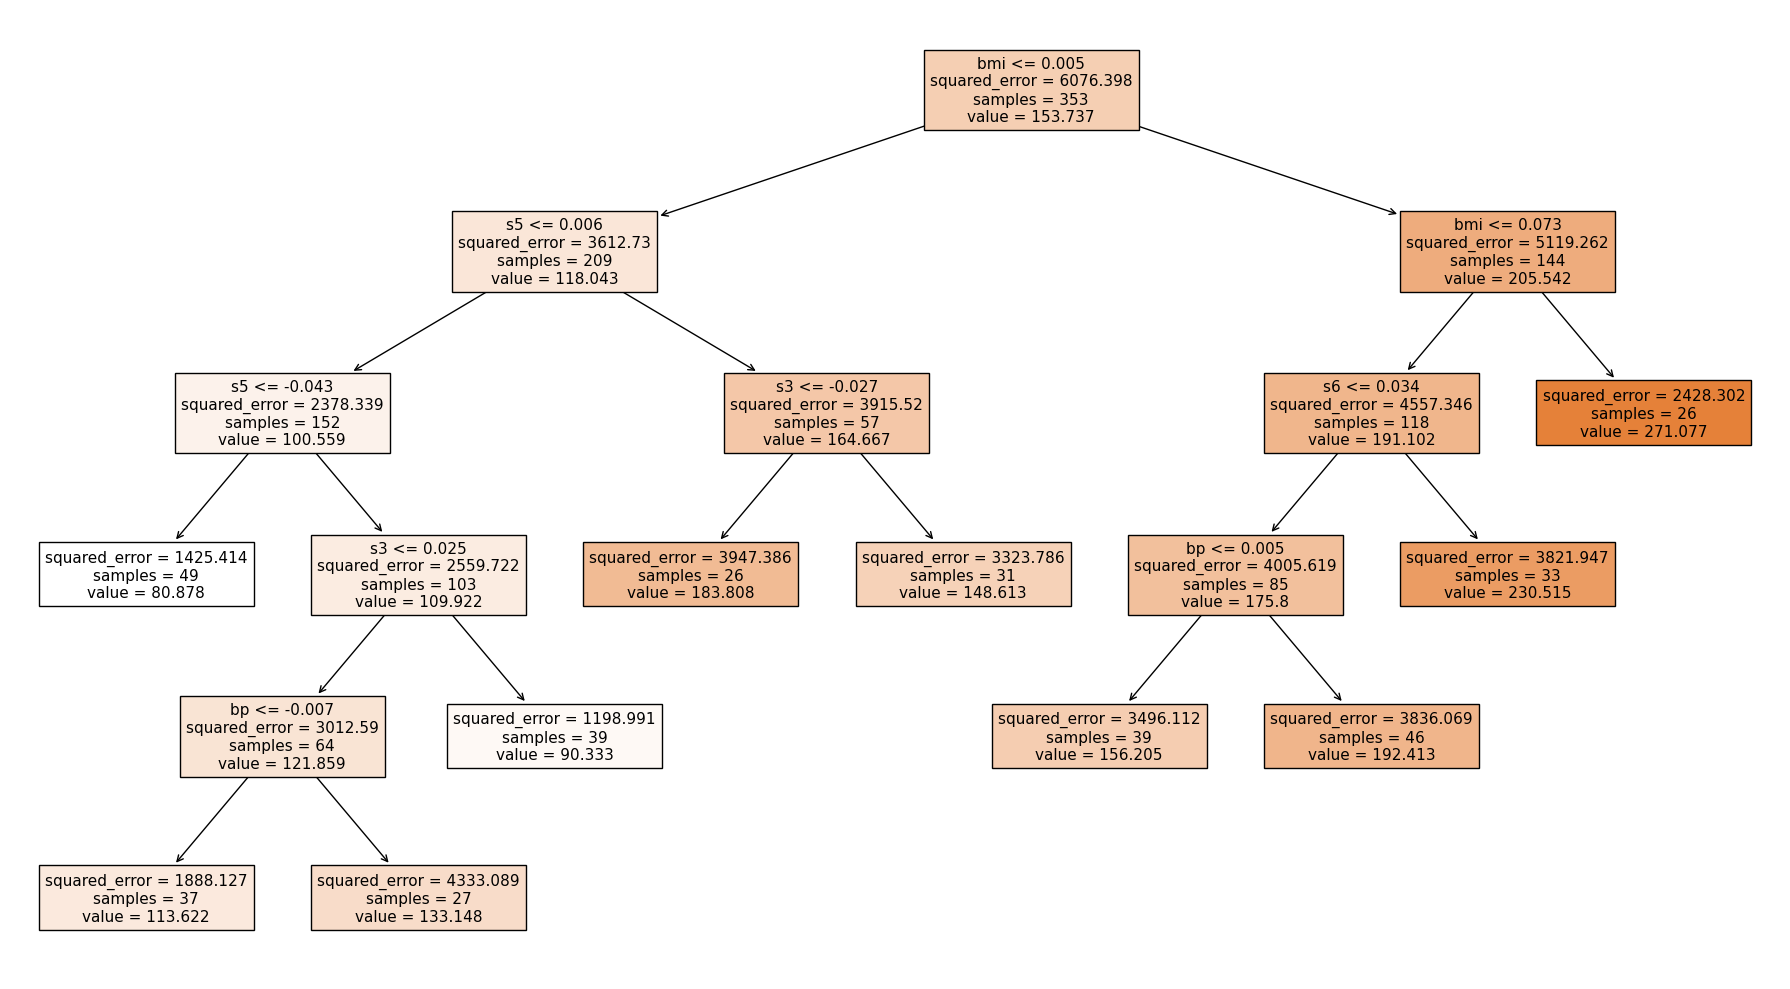

In [33]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()